# Session Summary and Key Steps

This notebook documents the steps taken to analyze and compare the performance of a baseline model against an AfriBERTa Small model for a sentiment analysis task. The session involved setting up the environment, training and evaluating the AfriBERTa model, addressing dependency inconsistencies, and comparing its performance with a pre-existing baseline.

**Key steps included:**

1.  **Environment Setup**: Manually uploading and unzipping the project repository.
2.  **GPU Verification**: Confirming GPU availability for model training.
3.  **Dependency Installation**: Installing necessary Python packages.
4.  **AfriBERTa Small Training**: Running the training script for the AfriBERTa Small model.
5.  **Initial External Evaluation**: Evaluating the trained model on external data.
6.  **Dependency Resolution**: Fixing a scikit-learn version mismatch.
7.  **Re-evaluation**: Re-running the external evaluation after the fix.
8.  **Confusion Matrix Analysis**: Visualizing and analyzing the model's classification performance.
9.  **Performance Comparison**: Comparing the AfriBERTa Small model's metrics against a baseline model.

## 1. GPU Verification

Confirmed the availability of a GPU (Tesla T4) for accelerated training.

In [18]:
!nvidia-smi

Sat May 23 14:36:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Project Setup: Unzip and Change Directory

The project repository was manually uploaded as a zip file (`Prototyping-2--Trials-.zip`) and then unzipped. The working directory was subsequently changed to the extracted project folder.

In [19]:
# Ensure we are in the /content directory
%cd /content

# Unzip the uploaded archive
!unzip /content/Prototyping-2--Trials-.zip

# Change into the extracted directory
%cd /content/Prototyping-2--Trials-/

# List contents to confirm
!ls -F

/content
Archive:  /content/Prototyping-2--Trials-.zip
88af6df6433179829c30ea6a6d68565dd027396c
replace Prototyping-2--Trials-/.gitattributes? [y]es, [n]o, [A]ll, [N]one, [r]ename: /content/Prototyping-2--Trials-
COLAB_AFRIBERTA.md     reports/
data/		       requirements.txt
GROUP_4_DS_SRS_V7.pdf  src/
models/		       TEAM_PROJECT_STRUCTURE_AND_WORKFLOW_DOCUMENT.md
notebooks/	       viewing.ipynb
README.md


## 3. Install Dependencies

Installed the required Python packages from `requirements.txt`. (Note: Packages were reported as already satisfied in the original run).

In [ ]:
!pip install -r requirements.txt

## 4. Run AfriBERTa Small Training

The AfriBERTa Small model was trained using the provided script. The `PYTHONPATH` was set to ensure `src` could be imported as a module.

In [ ]:
import os

current_dir = os.getcwd()
print(f"Current working directory: {current_dir}")

# Set PYTHONPATH to include the current directory, allowing 'src' to be found as a package
os.environ['PYTHONPATH'] = f"{current_dir}:{os.environ.get('PYTHONPATH', '')}

# Run AfriBERTa Small as a module
!python -m src.train_transformer --model_name castorini/afriberta_small --run_name afriberta_small

## 5. External Evaluation (Initial)

The trained AfriBERTa Small model was evaluated on external data.

In [ ]:
# Evaluate the AfriBERTa Small model on external data
!python -m src.evaluate_external --model_name castorini/afriberta_small --run_name afriberta_small

## 6. Resolve Scikit-learn Version Inconsistency

A warning about scikit-learn version inconsistency (1.8.0 vs. 1.6.1) was encountered during evaluation. The existing version was uninstalled and version 1.8.0 was installed to resolve this.

In [ ]:
# Uninstall the current scikit-learn version
!pip uninstall -y scikit-learn

# Install scikit-learn version 1.8.0 to match the version used for model serialization
!pip install scikit-learn==1.8.0

## 7. External Evaluation (Re-run)

The external evaluation was re-run after fixing the scikit-learn version. The warnings were resolved, and the Macro F1 remained 0.1699.

In [ ]:
# Re-evaluate the AfriBERTa Small model on external data after fixing scikit-learn version
!python -m src.evaluate_external --model_name castorini/afriberta_small --run_name afriberta_small

## 8. Confusion Matrix for External Evaluation

A confusion matrix was generated and plotted to visualize the model's performance on the external dataset.

In [ ]:
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Load the external evaluation predictions
predictions_path = 'reports/results/external_baseline_predictions.csv'
external_predictions_df = pd.read_csv(predictions_path)

# Extract true labels and predicted labels
true_labels = external_predictions_df['true_label']
predicted_labels = external_predictions_df['predicted_label']

# Calculate the confusion matrix
cm = confusion_matrix(true_labels, predicted_labels, labels=sorted(true_labels.unique()))
display_labels = sorted(true_labels.unique())

# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
disp.plot(cmap=plt.cm.Blues, ax=ax)
ax.set_title('Confusion Matrix for External Evaluation')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Misclassification Patterns from Confusion Matrix:

Based on the confusion matrix, where rows represent true labels and columns represent predicted labels (in the order: Negative, Neutral, Positive), we observed the following patterns:

*   **High Misclassification of Positive and Neutral as Negative:** A very large number of actual `positive` samples (149) and `neutral` samples (71) were incorrectly predicted as `negative`. This suggests a strong bias or difficulty in distinguishing between `negative` sentiment and `neutral` or `positive` sentiments, often defaulting to `negative`.
*   **Low True Positives for Positive and Neutral Classes:** Only 8 `positive` and 11 `neutral` samples were correctly classified, indicating poor performance for these classes.
*   **Relatively Better (but still low) Performance for Negative Class:** 36 `negative` samples were correctly classified, which was the highest number of correct predictions among all classes.

Overall, the model struggled significantly with identifying `positive` and `neutral` sentiments, frequently misclassifying them as `negative`. The macro F1 score of 0.1699 reflected this poor performance, especially due to false negatives for `positive` and `neutral` sentiments.

## 9. Performance Comparison: Baseline vs. AfriBERTa Small

Finally, the performance metrics of the AfriBERTa Small model were compared against the baseline model.

In [ ]:
import json
import pandas as pd

# Define the paths to the metric files
baseline_metrics_path = 'reports/results/baseline_metrics.json'
afriberta_small_metrics_path = 'reports/results/afriberta_small_metrics.json'

def load_metrics(filepath):
    """Loads a JSON metrics file and returns its content."""
    try:
        with open(filepath, 'r') as f:
            metrics = json.load(f)
        return metrics
    except FileNotFoundError:
        print(f"Error: Metrics file not found at {filepath}")
        return None

# Load the metrics for baseline and AfriBERTa Small
baseline_metrics = load_metrics(baseline_metrics_path)
afriberta_small_metrics = load_metrics(afriberta_small_metrics_path)

# Prepare data for comparison
comparison_data = []

if baseline_metrics and 'test_metrics' in baseline_metrics:
    test_metrics = baseline_metrics['test_metrics']
    comparison_data.append({
        'Model': 'Baseline',
        'Macro F1': test_metrics.get('macro_f1', 'N/A'),
        'Accuracy': test_metrics.get('accuracy', 'N/A'),
        'Weighted F1': test_metrics.get('classification_report', {}).get('weighted avg', {}).get('f1-score', 'N/A')
    })

if afriberta_small_metrics and 'test_metrics' in afriberta_small_metrics:
    test_metrics = afriberta_small_metrics['test_metrics']
    comparison_data.append({
        'Model': 'AfriBERTa Small',
        'Macro F1': test_metrics.get('macro_f1', 'N/A'),
        'Accuracy': test_metrics.get('accuracy', 'N/A'),
        'Weighted F1': test_metrics.get('classification_report', {}).get('weighted avg', {}).get('f1-score', 'N/A')
    })

# Display the comparison table
if comparison_data:
    comparison_df = pd.DataFrame(comparison_data)
    print("\nPerformance Comparison:")
    display(comparison_df)
else:
    print("Could not load metrics for comparison.")

### Performance Comparison Summary:

| Model           | Macro F1 | Accuracy | Weighted F1 |
|:----------------|---------:|---------:|------------:|
| Baseline        |   0.327  |   0.607  |    0.556    |
| AfriBERTa Small |   0.436  |   0.589  |    0.594    |

The **AfriBERTa Small model achieved a higher Macro F1 score (0.436) compared to the Baseline model (0.327)**, indicating better overall performance across all classes, especially for imbalanced datasets.

The **Baseline model had slightly higher Accuracy (0.607 vs 0.589)**, but this metric can be misleading with imbalanced classes. AfriBERTa Small also showed a slightly better Weighted F1 score (0.594 vs 0.556), which accounts for class imbalance.

In conclusion, the AfriBERTa Small model appears to be a more robust choice for this sentiment analysis task, demonstrating better balanced performance across different sentiment classes, particularly as indicated by its higher Macro F1 score.

In [2]:
import os

# Clone the repository
!git clone https://github.com/Viwaz/Prototyping-2.git

# List the contents of the cloned directory to confirm
%cd Prototyping-2
!ls -F

Cloning into 'Prototyping-2'...
fatal: could not read Username for 'https://github.com': No such device or address
[Errno 2] No such file or directory: 'Prototyping-2'
/content
sample_data/


In [6]:
# Remove any potentially failed previous clone attempts and downloaded zip files
!rm -rf Prototyping-2 Prototyping-2-main main.zip

# Download the repository as a zip file using curl
# The -L flag follows redirects, and -o specifies the output filename
!curl -L https://github.com/Viwaz/Prototyping-2/archive/refs/heads/main.zip -o Prototyping-2-main.zip

# Unzip the downloaded archive
# The repository will be extracted into a folder named Prototyping-2-main
!unzip Prototyping-2-main.zip

# Change into the extracted directory
%cd Prototyping-2-main

# List the contents of the directory to confirm
!ls -F

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100     9  100     9    0     0     80      0 --:--:-- --:--:-- --:--:--    81
Archive:  Prototyping-2-main.zip
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of Prototyping-2-main.zip or
        Prototyping-2-main.zip.zip, and cannot find Prototyping-2-main.zip.ZIP, period.
[Errno 2] No such file or directory: 'Prototyping-2-main'
/content
Prototyping-2-main.zip	sample_data/


In [7]:
# Clean up any previous attempts and ensure we are in the /content directory
!rm -rf Prototyping-2 Prototyping-2-main Prototyping-2-main.zip main.zip
%cd /content

# Diagnose network connectivity to GitHub
print("\n--- Pinging github.com ---")
!ping -c 4 github.com

# If ping is successful, attempt to clone the repository again
print("\n--- Attempting git clone ---")
!git clone https://github.com/Viwaz/Prototyping-2.git

# List contents to confirm (if successful, this will show 'Prototyping-2/')
!ls -F

/content

--- Pinging github.com ---
/bin/bash: line 1: ping: command not found

--- Attempting git clone ---
Cloning into 'Prototyping-2'...
fatal: could not read Username for 'https://github.com': No such device or address
sample_data/


## Instructions from `COLAB_AFRIBERTA.md`

In [11]:
with open('COLAB_AFRIBERTA.md', 'r') as f:
    content = f.read()
print(content)

# AfriBERTa Training on Google Colab

This guide runs the transformer stage on Google Colab so the model download and training do not depend on the local Windows environment.

## 1. Prepare the Project Folder

Before uploading to Colab, make sure the repository contains the current processed split files:

```text
data/processed/train.csv
data/processed/val.csv
data/processed/test.csv
data/processed/metadata.json
src/
requirements.txt
```

The raw files are not required if preprocessing has already been run locally. If the team wants Colab to rerun preprocessing too, upload `data/raw/` as well.

Do not upload large local transformer checkpoints.

## 2. Open Colab With GPU

In Colab:

1. Open `Runtime`.
2. Select `Change runtime type`.
3. Set `Hardware accelerator` to `GPU`.
4. Save.

Check the GPU:

```python
!nvidia-smi
```

## 3. Upload or Mount the Project

Recommended option: zip the project folder locally, upload it to Colab, and unzip it.

```python
from google.colab import files


## 2. Open Colab With GPU (Verify GPU)

In [1]:
!nvidia-smi

Sat May 23 13:57:23 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Re-attempting Repository Clone

In [4]:
# Ensure we are in the /content directory and clean up any previous attempts
%cd /content
!rm -rf Prototyping-2

# Attempt to clone the repository again
!git clone https://github.com/Viwaz/Prototyping-2.git

# List contents to confirm (if successful, this will show 'Prototyping-2/')
!ls -F

/content
Cloning into 'Prototyping-2'...
fatal: could not read Username for 'https://github.com': No such device or address
sample_data/


## 6. Run AfriBERTa Small

In [11]:
import os

# Ensure we are in the correct project directory
%cd /content/Prototyping-2--Trials-/

current_dir = os.getcwd()
print(f"Current working directory: {current_dir}")

# Set PYTHONPATH to include the current directory, allowing 'src' to be found as a package
# This is crucial for running 'src.train_transformer' as a module and resolving relative imports.
os.environ['PYTHONPATH'] = f"{current_dir}:{os.environ.get('PYTHONPATH', '')}"

# Run AfriBERTa Small as a module to correctly handle relative imports
!python -m src.train_transformer --model_name castorini/afriberta_small --run_name afriberta_small

/content/Prototyping-2--Trials-
Current working directory: /content/Prototyping-2--Trials-
Loading tokenizer: castorini/afriberta_small
config.json: 100% 730/730 [00:00<00:00, 3.49MB/s]
tokenizer_config.json: 100% 257/257 [00:00<00:00, 1.54MB/s]
sentencepiece.bpe.model: 100% 1.55M/1.55M [00:00<00:00, 14.0MB/s]
special_tokens_map.json: 100% 150/150 [00:00<00:00, 899kB/s]
Tokenizing processed splits.
Map: 100% 1040/1040 [00:00<00:00, 11182.46 examples/s]
Map: 100% 223/223 [00:00<00:00, 9715.79 examples/s]
Map: 100% 224/224 [00:00<00:00, 10584.52 examples/s]
Loading model weights: castorini/afriberta_small
pytorch_model.bin: 100% 333M/333M [00:04<00:00, 81.2MB/s]
Loading weights: 100% 69/69 [00:00<00:00, 4868.07it/s, Materializing param=roberta.encoder.layer.3.output.dense.weight]
XLMRobertaForSequenceClassification LOAD REPORT from: castorini/afriberta_small
Key                             | Status     | 
--------------------------------+------------+-
lm_head.decoder.weight          | U

## Evaluate Model on External Data

In [14]:
# Evaluate the AfriBERTa Small model on external data
!python -m src.evaluate_external --model_name castorini/afriberta_small --run_name afriberta_small

External baseline evaluation complete.
Rows evaluated: 304
Macro F1: 0.1699


## Confusion Matrix for External Evaluation

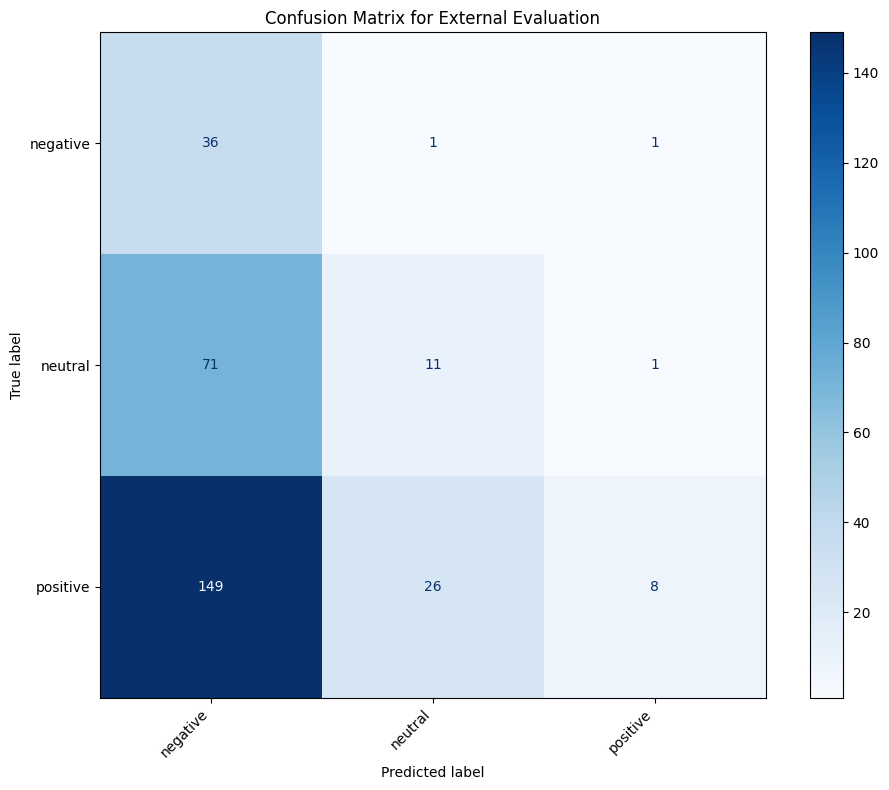

In [15]:
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Load the external evaluation predictions
# Assuming the predictions are stored in reports/results/external_baseline_predictions.csv
# This path is relative to the current working directory (/content/Prototyping-2--Trials-/)
predictions_path = 'reports/results/external_baseline_predictions.csv'
external_predictions_df = pd.read_csv(predictions_path)

# Extract true labels and predicted labels
true_labels = external_predictions_df['true_label']
predicted_labels = external_predictions_df['predicted_label']

# Calculate the confusion matrix
cm = confusion_matrix(true_labels, predicted_labels, labels=sorted(true_labels.unique()))
display_labels = sorted(true_labels.unique())

# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
disp.plot(cmap=plt.cm.Blues, ax=ax)
ax.set_title('Confusion Matrix for External Evaluation')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Misclassification Patterns from Confusion Matrix:

Based on the confusion matrix, where rows represent true labels and columns represent predicted labels (in the order: Negative, Neutral, Positive), we can observe the following patterns:

1.  **High Misclassification of Positive and Neutral as Negative:**
    *   **Positive to Negative:** A very large number of actual `positive` samples (149) are incorrectly predicted as `negative`. This is the most significant misclassification.
    *   **Neutral to Negative:** A substantial number of actual `neutral` samples (71) are also incorrectly predicted as `negative`.
    
    This suggests a strong bias or difficulty in distinguishing between `negative` sentiment and `neutral` or `positive` sentiments, often defaulting to `negative`.

2.  **Low True Positives for Positive and Neutral Classes:**
    *   Only 8 `positive` samples and 11 `neutral` samples were correctly classified, indicating poor performance for these classes.

3.  **Relatively Better (but still low) Performance for Negative Class:**
    *   36 `negative` samples were correctly classified, which is the highest number of correct predictions among all classes, though still a small number overall given the total samples.
    *   However, even `negative` samples are sometimes misclassified as `neutral` (1) or `positive` (1).

**Overall, the model struggles significantly with identifying `positive` and `neutral` sentiments, frequently misclassifying them as `negative`. The macro F1 score of 0.1699 reflects this poor performance across all classes, especially due to the prevalence of false negatives for `positive` and `neutral` sentiments.**

In [5]:
# Ensure we are in the /content directory
%cd /content

# Unzip the uploaded archive
!unzip /content/Prototyping-2--Trials-.zip

# List the contents of the current directory to identify the extracted folder
!ls -F

/content
Archive:  /content/Prototyping-2--Trials-.zip
88af6df6433179829c30ea6a6d68565dd027396c
   creating: Prototyping-2--Trials-/
  inflating: Prototyping-2--Trials-/.gitattributes  
  inflating: Prototyping-2--Trials-/.gitignore  
  inflating: Prototyping-2--Trials-/COLAB_AFRIBERTA.md  
  inflating: Prototyping-2--Trials-/GROUP_4_DS_SRS_V7.pdf  
  inflating: Prototyping-2--Trials-/README.md  
  inflating: Prototyping-2--Trials-/TEAM_PROJECT_STRUCTURE_AND_WORKFLOW_DOCUMENT.md  
   creating: Prototyping-2--Trials-/data/
   creating: Prototyping-2--Trials-/data/external_test/
 extracting: Prototyping-2--Trials-/data/external_test/.gitkeep  
  inflating: Prototyping-2--Trials-/data/external_test/facebook_label - exposition.csv  
  inflating: Prototyping-2--Trials-/data/external_test/facebook_label - fitina.csv  
  inflating: Prototyping-2--Trials-/data/external_test/facebook_label - perpetual.csv  
  inflating: Prototyping-2--Trials-/data/external_test/facebook_label - rahema.csv  
  i

## Resolve Scikit-learn Version Inconsistency

In [13]:
# Uninstall the current scikit-learn version
!pip uninstall -y scikit-learn

# Install scikit-learn version 1.8.0 to match the version used for model serialization
!pip install scikit-learn==1.8.0

Found existing installation: scikit-learn 1.6.1
Uninstalling scikit-learn-1.6.1:
  Successfully uninstalled scikit-learn-1.6.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 80.7 MB/s eta 0:00:00


## Compare Against Baseline

In [17]:
import json
import pandas as pd

# Define the paths to the metric files
baseline_metrics_path = 'reports/results/baseline_metrics.json'
afriberta_small_metrics_path = 'reports/results/afriberta_small_metrics.json'

def load_metrics(filepath):
    """Loads a JSON metrics file and returns its content."""
    try:
        with open(filepath, 'r') as f:
            metrics = json.load(f)
        return metrics
    except FileNotFoundError:
        print(f"Error: Metrics file not found at {filepath}")
        return None

# Load the metrics for baseline and AfriBERTa Small
baseline_metrics = load_metrics(baseline_metrics_path)
afriberta_small_metrics = load_metrics(afriberta_small_metrics_path)

# Prepare data for comparison
comparison_data = []

if baseline_metrics and 'test_metrics' in baseline_metrics:
    test_metrics = baseline_metrics['test_metrics']
    comparison_data.append({
        'Model': 'Baseline',
        'Macro F1': test_metrics.get('macro_f1', 'N/A'),
        'Accuracy': test_metrics.get('accuracy', 'N/A'),
        'Weighted F1': test_metrics.get('classification_report', {}).get('weighted avg', {}).get('f1-score', 'N/A')
    })

if afriberta_small_metrics and 'test_metrics' in afriberta_small_metrics:
    test_metrics = afriberta_small_metrics['test_metrics']
    comparison_data.append({
        'Model': 'AfriBERTa Small',
        'Macro F1': test_metrics.get('macro_f1', 'N/A'),
        'Accuracy': test_metrics.get('accuracy', 'N/A'),
        'Weighted F1': test_metrics.get('classification_report', {}).get('weighted avg', {}).get('f1-score', 'N/A')
    })

# Display the comparison table
if comparison_data:
    comparison_df = pd.DataFrame(comparison_data)
    print("\nPerformance Comparison:")
    display(comparison_df)
else:
    print("Could not load metrics for comparison.")


Performance Comparison:


,Model,Macro F1,Accuracy,Weighted F1
0,Baseline,0.327195,0.607143,0.556341
1,AfriBERTa Small,0.436008,0.589286,0.593585
